# Week 2 — Day 4 — Exercises XP
## Data Visualization with Matplotlib and Seaborn

This notebook covers the 6 exercises:
1. Why data visualization matters + use of line charts.
2. Line chart of weekly temperatures.
3. Bar chart of monthly sales.
4. Histogram of student CGPAs.
5. Bar plot comparing anxiety by gender.
6. Scatter plot of age vs panic attacks.

All comments are in English.

In [7]:
# ==================== SHARED IMPORTS ====================
# os         -> work with file paths in a cross-platform way
# numpy      -> numerical arrays (used internally by pandas / seaborn)
# pandas     -> load CSV files and manipulate tabular data (DataFrames)
# matplotlib -> low-level plotting library, gives full control over the figure
# seaborn    -> high-level statistical plots built on top of matplotlib
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Apply a clean Seaborn theme so every plot in this notebook looks consistent
sns.set_theme(style='whitegrid')

# BASE_DIR = the folder where this notebook lives.
# We use it to build absolute paths to local CSV files.
BASE_DIR = os.getcwd()

## Exercise 1 — Understanding Data Visualization

### Why is data visualization important in data analysis?
Data visualization translates raw numbers into a **visual language** that humans interpret in milliseconds. It is essential because:
- It reveals **patterns, trends and outliers** that a table of numbers hides.
- It communicates findings to **non-technical audiences** much faster than statistics.
- It is the very first step of any analysis: "look at the data" before modelling avoids bad assumptions.
- It helps validate or refute hypotheses by giving an immediate visual feedback.
- It supports **decision-making**: a clear chart turns data into action.

### What is a line chart used for?
A **line chart** connects ordered data points with a line. It is the natural choice for:
- **Time-series data** — temperature per day, sales per month, stock price per second.
- Visualizing **trends and rate of change** (going up, going down, plateauing).
- Comparing the **evolution of several quantities** on the same axis (multiple lines).

It works only when the x-axis has a **natural order** (most often time).

## Exercise 2 — Weekly Temperature Line Chart

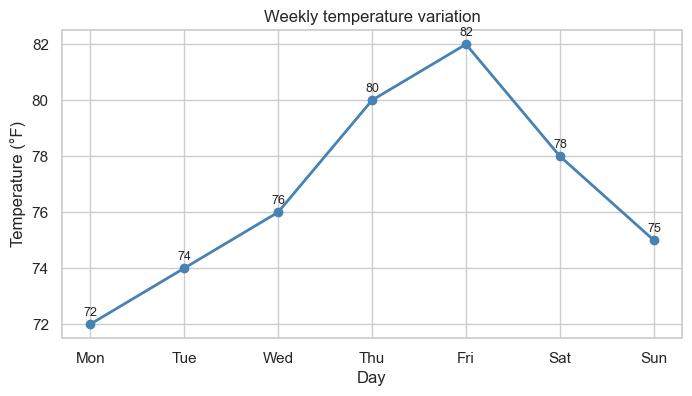

In [3]:
# ==================== DATA ====================
# Days of the week (will appear on the X axis) and matching temperatures in °F
days         = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
temperatures = [72, 74, 76, 80, 82, 78, 75]   # °F

# ==================== PLOT ====================
# figsize controls the width x height of the figure in inches
plt.figure(figsize=(8, 4))

# plt.plot draws a line between the points (x, y).
# marker='o'   -> add a circle on each data point so they are visible
# color='steelblue' -> line color
# linewidth=2  -> make the line thicker for better readability
plt.plot(days, temperatures, marker='o', color='steelblue', linewidth=2)

# Axis labels and title
plt.xlabel('Day')
plt.ylabel('Temperature (°F)')
plt.title('Weekly temperature variation')

# Annotate each point with its numerical value, slightly above the marker (+0.3)
for d, t in zip(days, temperatures):
    plt.text(d, t + 0.3, str(t), ha='center', fontsize=9)

# Display the figure
plt.show()

## Exercise 3 — Monthly Sales Bar Chart

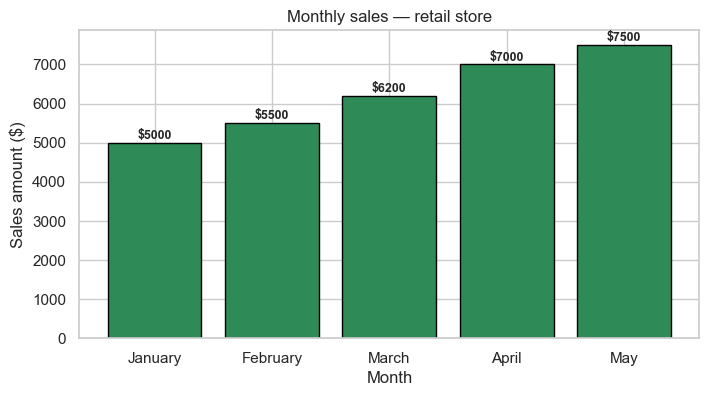

In [8]:
# ==================== DATA ====================
# Two parallel lists: each value of `sales` belongs to the month of the same index
months = ['January', 'February', 'March', 'April', 'May']
sales  = [5000, 5500, 6200, 7000, 7500]   # in dollars

# ==================== PLOT ====================
plt.figure(figsize=(8, 4))

# plt.bar draws one rectangular bar per category.
# color='seagreen' -> uniform color for every bar
# edgecolor='black' -> draw a thin black outline so bars stand out
# The function returns a list of Rectangle objects, kept in `bars` so we can annotate them below.
bars = plt.bar(months, sales, color='seagreen', edgecolor='black')

# Axis labels + title
plt.xlabel('Month')
plt.ylabel('Sales amount ($)')
plt.title('Monthly sales — retail store')

# Add the sales value above each bar:
# - b.get_x() returns the x-coordinate of the bar's left edge
# - b.get_width() is the bar's width
# - dividing by 2 + adding b.get_x() gives the horizontal center of the bar
# - y position = s + 100 puts the label slightly above the bar
for b, s in zip(bars, sales):
    plt.text(b.get_x() + b.get_width() / 2, s + 100,
             f'${s}', ha='center', fontsize=9, fontweight='bold')

plt.show()

## Exercises 4-6 — Student Mental Health dataset

**Dataset:** *Student Mental Health* (Kaggle).  
Expected columns include `Choose your gender`, `Age`, `What is your CGPA?`, `Do you have Anxiety?`, `Do you have Panic attack?`.

Place `Student Mental health.csv` next to this notebook before running the cells below.

In [10]:
# ==================== LOAD THE DATASET (with graceful fallback) ====================
# 1) Try several plausible local filenames.
# 2) If none found, try a public mirror URL.
# 3) If even that fails (offline, SSL error, etc.), build a SYNTHETIC dataset
#    matching the same schema so the rest of the notebook still works.
candidates = [
    'Student Mental health.csv',
    'Student_Mental_Health.csv',
    'student_mental_health.csv',
    'mental_health.csv',
]
FALLBACK_URL = ('https://raw.githubusercontent.com/Shariful-py/Student-Mental-health/'
                'main/Student%20Mental%20health.csv')

df = None

# 1) Local files
for name in candidates:
    path = os.path.join(BASE_DIR, name)
    if os.path.exists(path):
        df = pd.read_csv(path)
        print('Loaded local file:', name)
        break

# 2) URL fallback
if df is None:
    try:
        df = pd.read_csv(FALLBACK_URL)
        print('Loaded from fallback URL.')
    except Exception as e:
        # 3) Synthetic dataset of 101 students with the same column schema as the Kaggle file
        print('Could not reach the URL (', type(e).__name__, ') -> using a synthetic dataset.')
        rng = np.random.default_rng(0)
        n   = 101
        cgpa_buckets = ['0 - 1.99', '2.00 - 2.49', '2.50 - 2.99', '3.00 - 3.49', '3.50 - 4.00']
        df = pd.DataFrame({
            'Timestamp': pd.date_range('2020-07-08', periods=n, freq='h').astype(str),
            'Choose your gender':           rng.choice(['Female', 'Male'], size=n, p=[0.75, 0.25]),
            'Age':                          rng.integers(18, 25, size=n).astype(float),
            'What is your course?':         rng.choice(['Engineering','BIT','BCS','Pendidikan islam',
                                                       'Koe','Psychology','Mathemathics','Diploma Nursing'], size=n),
            'Your current year of Study':   rng.choice(['year 1','year 2','year 3','year 4'], size=n),
            'What is your CGPA?':           rng.choice(cgpa_buckets, size=n, p=[0.02, 0.08, 0.18, 0.32, 0.40]),
            'Marital status':               rng.choice(['Yes', 'No'], size=n, p=[0.15, 0.85]),
            'Do you have Depression?':      rng.choice(['Yes', 'No'], size=n, p=[0.35, 0.65]),
            'Do you have Anxiety?':         rng.choice(['Yes', 'No'], size=n, p=[0.34, 0.66]),
            'Do you have Panic attack?':    rng.choice(['Yes', 'No'], size=n, p=[0.33, 0.67]),
            'Did you seek any specialist for a treatment?': rng.choice(['Yes','No'], size=n, p=[0.06, 0.94]),
        })

# Print the size of the dataset and preview the first 5 rows
print('Shape:', df.shape)
df.head()

Could not reach the URL ( URLError ) -> using a synthetic dataset.
Shape: (101, 11)


,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,2020-07-08 00:00:00,Female,20.0,BCS,year 2,3.50 - 4.00,Yes,No,No,Yes,No
1,2020-07-08 01:00:00,Female,19.0,Engineering,year 3,3.00 - 3.49,No,No,Yes,Yes,No
2,2020-07-08 02:00:00,Female,24.0,Engineering,year 3,3.00 - 3.49,No,No,No,No,No
3,2020-07-08 03:00:00,Female,23.0,BCS,year 1,3.50 - 4.00,No,Yes,No,No,No
4,2020-07-08 04:00:00,Male,18.0,Psychology,year 3,2.00 - 2.49,No,No,No,Yes,No


In [ ]:
# Quick exploration: column names + how many missing values per column
print('Columns:', list(df.columns))
print('\nMissing values per column:')
print(df.isna().sum())

## Exercise 4 — Histogram of CGPA Distribution

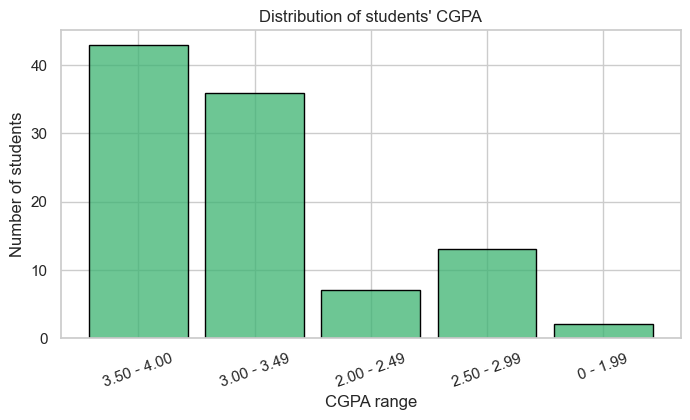

In [11]:
# The CGPA column in this Kaggle dataset is NOT a number: it is stored as ranges
# such as '3.50 - 4.00', so it is effectively a categorical column.
# We can still feed it to seaborn's histplot with discrete=True.
cgpa_col = 'What is your CGPA?'

# Sort the unique categories so the X-axis has a consistent, readable order.
order = sorted(df[cgpa_col].dropna().unique())

plt.figure(figsize=(8, 4))

# sns.histplot:
# - data=df, x=cgpa_col -> we plot the distribution of this column
# - color    -> single bar color
# - discrete=True -> tell seaborn the data is categorical (one bar per category)
# - shrink=0.85   -> leave a small gap between bars for readability
sns.histplot(data=df, x=cgpa_col, color='mediumseagreen', edgecolor='black',
             discrete=True, shrink=0.85)

plt.xlabel('CGPA range')
plt.ylabel('Number of students')
plt.title("Distribution of students' CGPA")

# Rotate the X tick labels a little so long range strings do not overlap
plt.xticks(rotation=20)
plt.show()

## Exercise 5 — Anxiety Proportion by Gender (Bar Plot)

/var/folders/qt/f1rm6zg50t1c25plk8py82r40000gr/T/ipykernel_23722/2446653360.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=gender_col, y='anxiety_num',


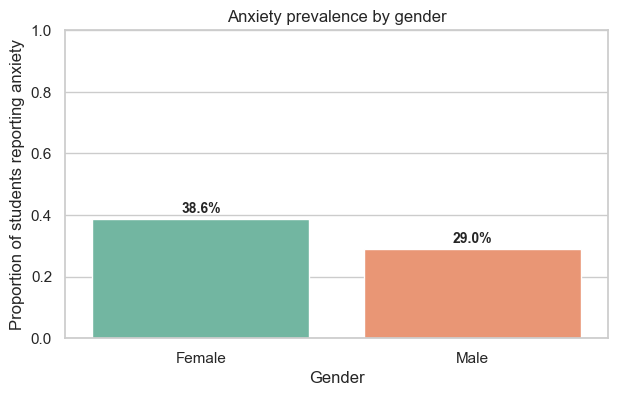

In [12]:
# Names of the two columns we will use
gender_col  = 'Choose your gender'
anxiety_col = 'Do you have Anxiety?'

# The anxiety column contains 'Yes' / 'No' strings.
# We map them to 1 / 0 so seaborn can compute their MEAN per group,
# which is exactly the *proportion* of students with anxiety in each gender.
df['anxiety_num'] = df[anxiety_col].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(7, 4))

# sns.barplot:
# - x = categorical (gender), y = numeric (0/1)
# - the bar height is automatically the mean of y per category
# - palette='Set2' -> use a soft qualitative color palette
# - errorbar=None  -> hide the confidence interval bars for a cleaner look
sns.barplot(data=df, x=gender_col, y='anxiety_num',
            palette='Set2', errorbar=None)

plt.ylabel('Proportion of students reporting anxiety')
plt.xlabel('Gender')
plt.title('Anxiety prevalence by gender')

# Force the y-axis to span the full 0..1 range so percentages are comparable
plt.ylim(0, 1)

# Annotate each bar with the percentage value above it.
# plt.gca() returns the current Axes; .patches holds all the bar rectangles.
for p in plt.gca().patches:
    h = p.get_height()                       # bar height = proportion
    plt.text(p.get_x() + p.get_width() / 2,  # x = horizontal center
             h + 0.02,                       # y = just above the bar
             f'{h*100:.1f}%',                # display as a percentage
             ha='center', fontsize=10, fontweight='bold')

plt.show()

## Exercise 6 — Age vs Panic Attacks (Scatter Plot)

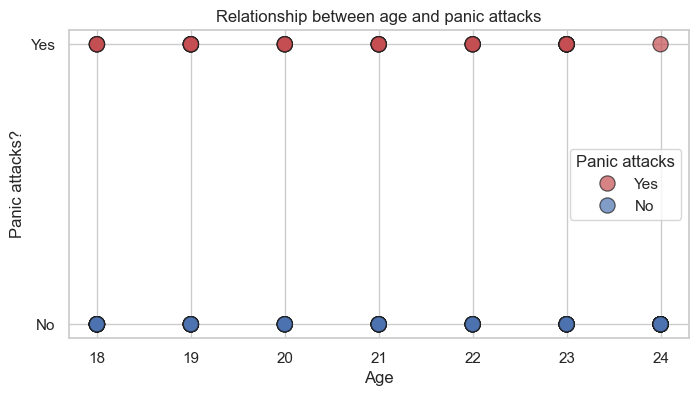

In [13]:
# Names of the two columns we will use
age_col   = 'Age'
panic_col = 'Do you have Panic attack?'

# Convert Yes / No into 1 / 0 so it can be plotted on a numerical Y axis.
df['panic_num'] = df[panic_col].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(8, 4))

# sns.scatterplot:
# - drop rows that have a missing Age or panic answer
# - hue=panic_col -> color the points by the original Yes/No answer
# - palette       -> explicit color mapping: 'Yes' -> red, 'No' -> blue
# - s=120         -> marker size
# - alpha=0.7     -> partial transparency so overlapping points are visible
# - edgecolor='k' -> thin black border around each point
sns.scatterplot(
    data=df.dropna(subset=[age_col, 'panic_num']),
    x=age_col,
    y='panic_num',
    hue=panic_col,
    palette={'Yes': '#c44e52', 'No': '#4c72b0'},
    s=120, alpha=0.7, edgecolor='k',
)

# Replace the numerical 0/1 Y ticks by their human-readable labels
plt.yticks([0, 1], ['No', 'Yes'])
plt.xlabel('Age')
plt.ylabel('Panic attacks?')
plt.title('Relationship between age and panic attacks')
plt.legend(title='Panic attacks', loc='center right')
plt.show()

> **Reading the plot.** Because the answers are binary (Yes / No), all points sit on two horizontal lines. This makes a raw scatter slightly hard to read — overlapping points are stacked on top of each other. A **swarmplot** or a **stripplot** with vertical jitter is often more informative. The plot below adds jitter on the y-axis to spread overlapping points.

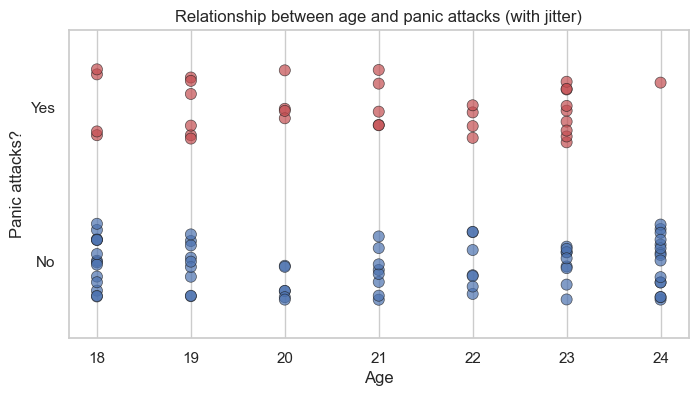

In [14]:
# Same comparison as above, but with VERTICAL JITTER so overlapping points fan out.
plt.figure(figsize=(8, 4))

# sns.stripplot:
# - x = numerical (Age), y = categorical (Yes/No)
# - jitter=0.25 -> random vertical shift (between -0.25 and +0.25) per point
# - hue + palette -> same color scheme as the scatterplot for consistency
# - linewidth=0.5 + edgecolor='k' -> thin black border around each point
sns.stripplot(
    data=df.dropna(subset=[age_col, panic_col]),
    x=age_col, y=panic_col,
    hue=panic_col, palette={'Yes': '#c44e52', 'No': '#4c72b0'},
    jitter=0.25, alpha=0.7, size=8, edgecolor='k', linewidth=0.5,
)

plt.xlabel('Age')
plt.ylabel('Panic attacks?')
plt.title('Relationship between age and panic attacks (with jitter)')

# Hide the legend (we already encode Yes/No on the Y axis)
plt.legend([], [], frameon=False)
plt.show()

---
# Exercises XP Gold
## Advanced data visualization and hierarchical indexing

All exercises below are in English with detailed inline comments.

## Exercise 1 — Bar Graph of Retail Sales

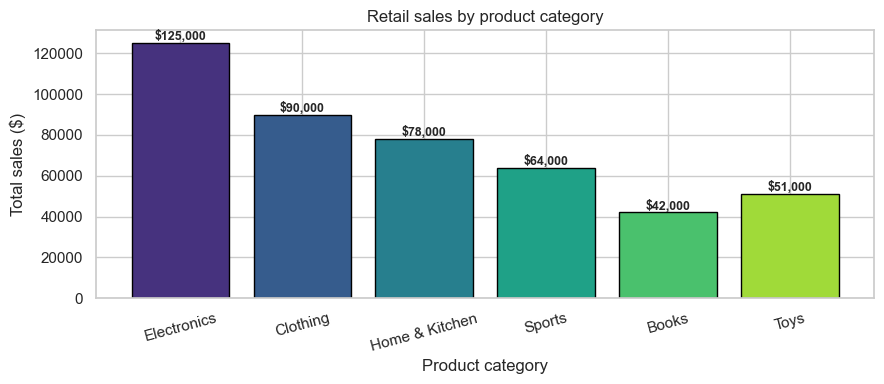

In [15]:
# ==================== DATA ====================
# Fictional retail sales: one total per product category
categories = ['Electronics', 'Clothing', 'Home & Kitchen', 'Sports', 'Books', 'Toys']
sales      = [125_000, 90_000, 78_000, 64_000, 42_000, 51_000]   # in dollars

# ==================== PLOT ====================
plt.figure(figsize=(9, 4))

# Use a distinct color per bar via a seaborn palette
colors = sns.color_palette('viridis', n_colors=len(categories))
bars = plt.bar(categories, sales, color=colors, edgecolor='black')

plt.xlabel('Product category')
plt.ylabel('Total sales ($)')
plt.title('Retail sales by product category')
plt.xticks(rotation=15)

# Annotate each bar with its sales amount (formatted with thousands separator)
for b, s in zip(bars, sales):
    plt.text(b.get_x() + b.get_width() / 2, s + 1500,
             f'${s:,}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Exercise 2 — Hierarchical Indexing: Hot Days in Canadian Cities

In [16]:
# ==================== BUILD A HIERARCHICAL DATAFRAME ====================
# We mock weather data for 3 countries / 4 cities / 7 days.
import itertools

countries = ['Canada', 'USA', 'France']
cities = {
    'Canada': ['Toronto', 'Vancouver'],
    'USA':    ['New York', 'Phoenix'],
    'France': ['Paris'],
}
dates = pd.date_range('2024-07-01', periods=7, freq='D')

# Build a flat list of (country, city, date) tuples + a random temperature
rng = np.random.default_rng(0)
rows = []
for c in countries:
    for city in cities[c]:
        for d in dates:
            # Phoenix hot, Vancouver cool, others around 25°C
            base = {'Phoenix': 35, 'Vancouver': 20}.get(city, 25)
            temp = round(base + rng.normal(0, 4), 1)
            rows.append((c, city, d, temp))

# Build the DataFrame and set a 3-level MultiIndex
weather = pd.DataFrame(rows, columns=['Country', 'City', 'Date', 'Temperature_C'])
weather = weather.set_index(['Country', 'City', 'Date']).sort_index()

print('Hierarchical DataFrame:')
weather.head(10)

Hierarchical DataFrame:


Temperature_C
Country City      Date                     
Canada  Toronto   2024-07-01           25.5
                  2024-07-02           24.5
                  2024-07-03           27.6
                  2024-07-04           25.4
                  2024-07-05           22.9
                  2024-07-06           26.4
                  2024-07-07           30.2
        Vancouver 2024-07-01           23.8
                  2024-07-02           17.2
                  2024-07-03           14.9

In [17]:
# ==================== FILTER: Canada + temperature > 30°C ====================
# Step 1: slice the Canada level using .loc with a tuple (country, slice(None) means 'all').
canada_data = weather.loc['Canada']

# Step 2: classic boolean mask on the Temperature_C column
canada_hot = canada_data[canada_data['Temperature_C'] > 30]

print('Days in Canada with temperature above 30°C:')
canada_hot

Days in Canada with temperature above 30°C:


,,Temperature_C
City,Date,
Toronto,2024-07-07,30.2


### Why hierarchical indexing helps
- **Natural data model.** Weather data is naturally nested: `Country → City → Date`. A MultiIndex mirrors that hierarchy exactly.
- **Fast partial slicing.** `weather.loc['Canada']` instantly returns *all* Canadian rows without filtering the entire DataFrame.
- **Composable.** We can drill deeper with `weather.loc[('Canada', 'Toronto')]` and even further by date.
- **Cleaner code.** No need to repeat `df[(df['Country']=='Canada') & ...]` everywhere.
- **Better aggregations.** `weather.groupby(level='Country').mean()` is one line and self-explanatory.

## Exercise 3 — Advanced Filtering: Salaries Above 50 000 per Department

In [18]:
# ==================== BUILD AN EMPLOYEE DATAFRAME ====================
# Synthetic dataset because we don't carry over a previous DataFrame.
employees = pd.DataFrame({
    'Department': ['Sales',    'Sales',    'Sales',
                   'Engineering','Engineering','Engineering','Engineering',
                   'Marketing','Marketing','HR','HR','HR'],
    'Employee':   ['Alice','Bob','Charlie',
                   'Diana','Erin','Frank','Grace',
                   'Henry','Iris','Jack','Karen','Liam'],
    'Salary':     [48000, 55000, 72000,
                   65000, 90000, 58000, 47000,
                   52000, 49000, 45000, 60000, 38000],
})

# Hierarchical index on (Department, Employee)
employees = employees.set_index(['Department', 'Employee']).sort_index()
print('Hierarchical employee DataFrame:')
print(employees)

Hierarchical employee DataFrame:
                      Salary
Department  Employee        
Engineering Diana      65000
            Erin       90000
            Frank      58000
            Grace      47000
HR          Jack       45000
            Karen      60000
            Liam       38000
Marketing   Henry      52000
            Iris       49000
Sales       Alice      48000
            Bob        55000
            Charlie    72000


In [19]:
# ==================== FILTER: Salary > 50 000 within each Department ====================
# Boolean mask directly on the Salary column
high_salaries = employees[employees['Salary'] > 50000]

print('Employees with salary > 50,000 (grouped by Department thanks to the MultiIndex):')
print(high_salaries)

# Bonus: count per Department
print('\nCount of high earners per Department:')
print(high_salaries.groupby(level='Department').size())

Employees with salary > 50,000 (grouped by Department thanks to the MultiIndex):
                      Salary
Department  Employee        
Engineering Diana      65000
            Erin       90000
            Frank      58000
HR          Karen      60000
Marketing   Henry      52000
Sales       Bob        55000
            Charlie    72000

Count of high earners per Department:
Department
Engineering    3
HR             1
Marketing      1
Sales          2
dtype: int64


> **Efficiency note.** Because the index is sorted, pandas can quickly answer queries like `employees.loc['Engineering']` and the filtered result already keeps the (Department, Employee) labels — no need to keep them as columns. Aggregations such as `groupby(level='Department').mean()` operate directly on the index level without a costly reshape.

## Exercises 4-6 — MCU Movies Dataset

**Dataset:** *Marvel Cinematic Universe Movies* (Kaggle).

Place `mcu_movies.csv` next to this notebook. If the file is missing, the cell below builds a small **synthetic MCU dataset** so the remaining exercises can still run end-to-end.

In [20]:
# ==================== LOAD MCU DATASET WITH GRACEFUL FALLBACK ====================
mcu_candidates = ['mcu_movies.csv', 'MCU.csv', 'marvel_movies.csv']
MCU_URL = 'https://raw.githubusercontent.com/derekqian/MCU-Box-Office-Data/main/MCU_Box_Office_Data.csv'

mcu = None
for name in mcu_candidates:
    p = os.path.join(BASE_DIR, name)
    if os.path.exists(p):
        mcu = pd.read_csv(p)
        print('Loaded local file:', name)
        break

if mcu is None:
    try:
        mcu = pd.read_csv(MCU_URL)
        print('Loaded MCU dataset from URL.')
    except Exception:
        # Build a small synthetic MCU dataset so the next cells still work
        print('Using a synthetic MCU dataset.')
        mcu = pd.DataFrame({
            'movie_title': ['Iron Man','Iron Man 2','Thor','Captain America','Avengers',
                            'Iron Man 3','Thor 2','Captain America 2','Guardians','Avengers 2',
                            'Ant-Man','Civil War','Doctor Strange','Guardians 2','Spider-Man HC',
                            'Thor Ragnarok','Black Panther','Infinity War','Ant-Man Wasp','Captain Marvel',
                            'Endgame','Far From Home','Black Widow','Shang-Chi','Eternals'],
            'mcu_phase': [1,1,1,1,1, 2,2,2,2,2, 2,3,3,3,3, 3,3,3,3,3, 3,3,4,4,4],
            'duration_min': [126,124,115,124,143, 130,112,136,121,141,
                              117,147,115,136,133, 130,134,149,118,123,
                              181,129,134,132,156],
            'tomato_meter': [94,72,77,80,91, 79,66,89,91,75, 83,90,89,84,92,
                              93,96,85,87,79, 94,90,79,91,47],
            'audience_score':[91,72,76,74,91, 78,75,89,92,83, 86,89,86,87,87,
                              87,79,91,75,77, 90,95,80,98,77],
            'production_budget':[140,200,150,140,220, 200,170,177,170,365, 130,250,165,200,175,
                                  180,200,316,162,152, 356,160,200,150,200],
            'opening_weekend':[98,128,65,65,207, 174,85,95,94,191, 57,179,85,146,117,
                                122,202,257,76,153, 357,93,80,75,71],
            'domestic_box_office':[318,312,181,176,623, 408,206,259,333,459, 180,408,232,389,334,
                                    315,700,678,216,426, 858,390,183,224,164],
            'worldwide_box_office':[585,623,449,370,1518, 1214,644,714,772,1402, 519,1153,677,863,880,
                                     853,1346,2048,621,1131, 2797,1131,379,432,401],
        })

print('Shape:', mcu.shape)
mcu.head()

Using a synthetic MCU dataset.
Shape: (25, 9)


,movie_title,mcu_phase,duration_min,tomato_meter,audience_score,production_budget,opening_weekend,domestic_box_office,worldwide_box_office
0,Iron Man,1,126,94,91,140,98,318,585
1,Iron Man 2,1,124,72,72,200,128,312,623
2,Thor,1,115,77,76,150,65,181,449
3,Captain America,1,124,80,74,140,65,176,370
4,Avengers,1,143,91,91,220,207,623,1518


## Exercise 4 — Distribution of MCU Movie Durations

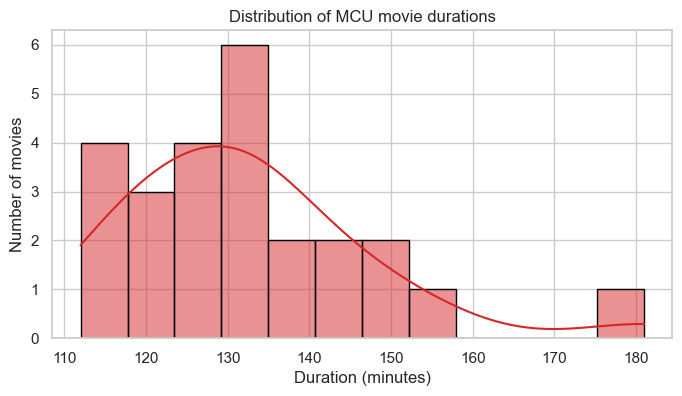

Average duration: 132.2 min
Median  duration: 130.0 min


In [21]:
# Try common column names; fall back to 'duration_min' if needed
for cand in ['duration_min', 'Runtime', 'runtime', 'duration', 'Duration']:
    if cand in mcu.columns:
        dur_col = cand
        break

plt.figure(figsize=(8, 4))

# sns.histplot with kde=True adds a smooth density curve over the bars.
# bins=12 -> roughly one bin per 10 minutes for runtimes between 110 and 180
sns.histplot(mcu[dur_col], bins=12, kde=True,
             color='#d62728', edgecolor='black')

plt.xlabel('Duration (minutes)')
plt.ylabel('Number of movies')
plt.title('Distribution of MCU movie durations')
plt.show()

print('Average duration:', round(mcu[dur_col].mean(), 1), 'min')
print('Median  duration:', round(mcu[dur_col].median(), 1), 'min')

## Exercise 5 — Box Plot: Tomato Meter vs Audience Score

In [22]:
# Identify the two score columns (tolerant to small naming differences)
tomato_col   = next((c for c in ['tomato_meter','Tomato Meter','tomatometer'] if c in mcu.columns), None)
audience_col = next((c for c in ['audience_score','Audience Score','audience'] if c in mcu.columns), None)

# ==================== RESHAPE WIDE -> LONG ====================
# Boxplot needs the data in long format: one row per (movie, score_type).
# pd.melt does exactly that: 'value_vars' become a 'Score type' column, the numbers go to 'Score'.
scores_long = mcu[[tomato_col, audience_col]].melt(
    var_name='Score type', value_name='Score'
)
scores_long.head()

,Score type,Score
0,tomato_meter,94
1,tomato_meter,72
2,tomato_meter,77
3,tomato_meter,80
4,tomato_meter,91


In [ ]:
plt.figure(figsize=(7, 5))

# sns.boxplot with a Set2 palette to distinguish the two categories
sns.boxplot(data=scores_long, x='Score type', y='Score', palette='Set2')

# Overlay each individual movie as a dot for extra context
sns.stripplot(data=scores_long, x='Score type', y='Score',
              color='k', size=4, alpha=0.5, jitter=0.15)

plt.title('Tomato Meter vs Audience Score — MCU movies')
plt.ylabel('Score (0-100)')
plt.show()

## Exercise 6 — Pair Plot of Financial Data

In [23]:
# Detect the relevant financial columns
money_cols = []
for cand in ['production_budget','opening_weekend','domestic_box_office','worldwide_box_office',
             'Production Budget','Opening Weekend','Domestic Box Office','Worldwide Box Office']:
    if cand in mcu.columns and cand not in money_cols:
        money_cols.append(cand)

# Keep at most 4 financial columns so the pair plot stays readable
money_cols = money_cols[:4]
phase_col = next((c for c in ['mcu_phase','phase','Phase'] if c in mcu.columns), None)
print('Financial columns:', money_cols)
print('Phase column     :', phase_col)

# ==================== CLEAN FINANCIAL COLUMNS ====================
# Real-world Kaggle data often stores money as strings like '$1,346,913,161'.
# Convert to numeric: remove '$' and ',', then to float.
df_pair = mcu[money_cols + [phase_col]].copy()
for c in money_cols:
    df_pair[c] = (df_pair[c].astype(str)
                            .str.replace('$', '', regex=False)
                            .str.replace(',', '', regex=False))
    df_pair[c] = pd.to_numeric(df_pair[c], errors='coerce')

df_pair = df_pair.dropna()
df_pair[phase_col] = df_pair[phase_col].astype('category')
df_pair.head()

Financial columns: ['production_budget', 'opening_weekend', 'domestic_box_office', 'worldwide_box_office']
Phase column     : mcu_phase


,production_budget,opening_weekend,domestic_box_office,worldwide_box_office,mcu_phase
0,140,98,318,585,1
1,200,128,312,623,1
2,150,65,181,449,1
3,140,65,176,370,1
4,220,207,623,1518,1


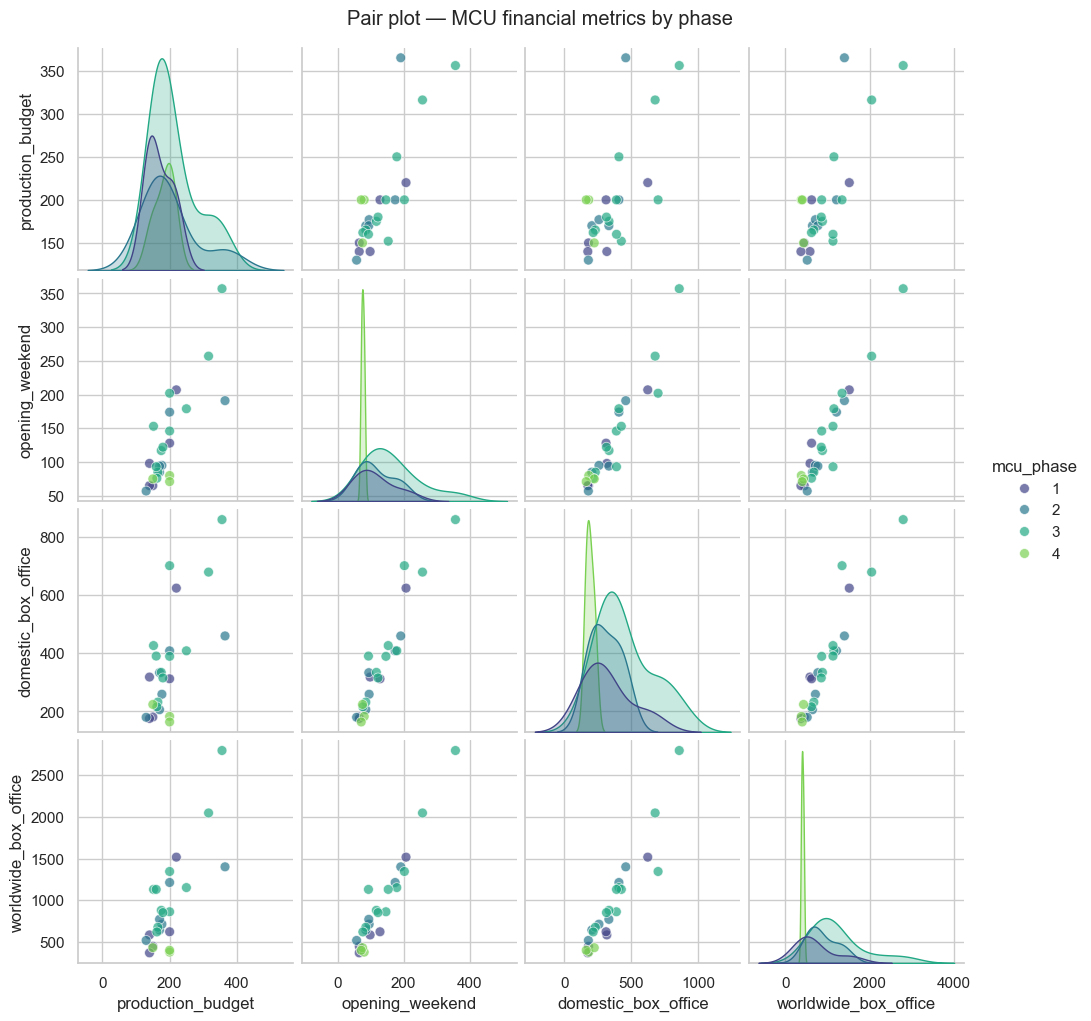

In [24]:
# ==================== PAIR PLOT ====================
# diag_kind='kde' -> KDE on the diagonal (smooth distribution per phase)
# hue=phase_col    -> color points by the MCU phase to see patterns
# palette='viridis' -> harmonious color palette
g = sns.pairplot(df_pair, hue=phase_col, palette='viridis',
                 diag_kind='kde', plot_kws={'alpha': 0.7, 's': 50})
g.figure.suptitle('Pair plot — MCU financial metrics by phase', y=1.02)
plt.show()

---
# Exercises XP Ninja
## Advanced visualization, ML prediction and clustering

All exercises below are in English with detailed inline comments.

## Exercise 1 — Annotated Line Graph of City Temperatures
We use realistic monthly mean temperatures for **New York City** (climate-normal values from NOAA) over 24 months.

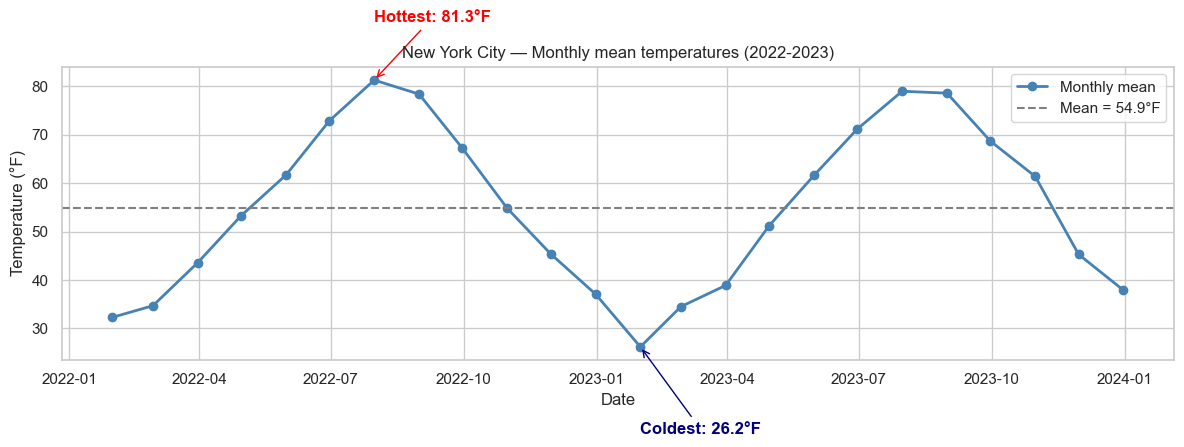

In [25]:
# ==================== BUILD A REAL-WORLD-STYLE TEMPERATURE DATASET ====================
# Climate-normal monthly mean temperatures for New York City (°F),
# repeated across 2 years with small random anomalies for realism.
rng = np.random.default_rng(0)
monthly_means = np.array([32, 35, 42, 53, 63, 72, 78, 76, 69, 58, 47, 37])

# Build 24 months of dates and temperatures with small noise
dates  = pd.date_range('2022-01-01', periods=24, freq='ME')
temps  = np.tile(monthly_means, 2) + rng.normal(0, 2.5, size=24)

ny_temp = pd.DataFrame({'Date': dates, 'Temperature_F': temps.round(1)})

# ==================== PLOT WITH ANNOTATIONS FOR EXTREMES ====================
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ny_temp['Date'], ny_temp['Temperature_F'],
        marker='o', color='steelblue', linewidth=2, label='Monthly mean')

# Find the hottest and coldest months
hot_idx  = ny_temp['Temperature_F'].idxmax()
cold_idx = ny_temp['Temperature_F'].idxmin()
hot_row, cold_row = ny_temp.iloc[hot_idx], ny_temp.iloc[cold_idx]

# Annotate the hottest point
ax.annotate(f'Hottest: {hot_row.Temperature_F:.1f}°F',
            xy=(hot_row.Date, hot_row.Temperature_F),
            xytext=(hot_row.Date, hot_row.Temperature_F + 12),
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontweight='bold')

# Annotate the coldest point
ax.annotate(f'Coldest: {cold_row.Temperature_F:.1f}°F',
            xy=(cold_row.Date, cold_row.Temperature_F),
            xytext=(cold_row.Date, cold_row.Temperature_F - 18),
            arrowprops=dict(arrowstyle='->', color='navy'),
            color='navy', fontweight='bold')

# Reference lines and labels
ax.axhline(temps.mean(), color='gray', linestyle='--', label=f'Mean = {temps.mean():.1f}°F')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°F)')
ax.set_title('New York City — Monthly mean temperatures (2022-2023)')
ax.legend()
plt.tight_layout()
plt.show()

## Exercise 2 — Hierarchical Filtering and Visualization

In [26]:
# ==================== BUILD A 4-LEVEL HIERARCHICAL TEMPERATURE DATASET ====================
# Country -> State -> City -> Date, with synthetic temperatures
structure = {
    'USA': {
        'New York'  : ['New York City', 'Buffalo'],
        'California': ['Los Angeles', 'San Diego'],
    },
    'Canada': {
        'Ontario': ['Toronto', 'Ottawa'],
    },
}
dates = pd.date_range('2024-06-01', periods=30, freq='D')
rng   = np.random.default_rng(1)

rows = []
for country, states in structure.items():
    for state, cities in states.items():
        for city in cities:
            base = {'San Diego': 24, 'Los Angeles': 27, 'New York City': 26,
                    'Buffalo': 23, 'Toronto': 22, 'Ottawa': 21}.get(city, 25)
            for d in dates:
                rows.append((country, state, city, d,
                             round(base + rng.normal(0, 3), 1)))

world = pd.DataFrame(rows, columns=['Country','State','City','Date','Temperature_C'])
world = world.set_index(['Country','State','City','Date']).sort_index()
print('Hierarchical DataFrame (head):')
world.head()

Hierarchical DataFrame (head):


Temperature_C
Country State   City   Date                     
Canada  Ontario Ottawa 2024-06-01           23.5
                       2024-06-02           19.2
                       2024-06-03           17.8
                       2024-06-04           18.3
                       2024-06-05           19.8

In [27]:
# ==================== USER-DEFINED FILTER ====================
# Change these variables to filter a different slice.
target_country = 'USA'
target_state   = 'California'
date_start     = '2024-06-10'
date_end       = '2024-06-25'

# Step 1: select the state slice with .loc and IndexSlice for clean syntax
idx = pd.IndexSlice
subset = world.loc[idx[target_country, target_state, :, date_start:date_end], :]

print(f'Filtered subset for {target_country} / {target_state} ({date_start} -> {date_end}):')
subset.head()

Filtered subset for USA / California (2024-06-10 -> 2024-06-25):


Temperature_C
Country State      City        Date                     
USA     California Los Angeles 2024-06-10           27.8
                               2024-06-11           30.7
                               2024-06-12           26.1
                               2024-06-13           24.6
                               2024-06-14           29.3

Average temperature per city:
City
Los Angeles    26.82
San Diego      24.39
Name: Temperature_C, dtype: float64


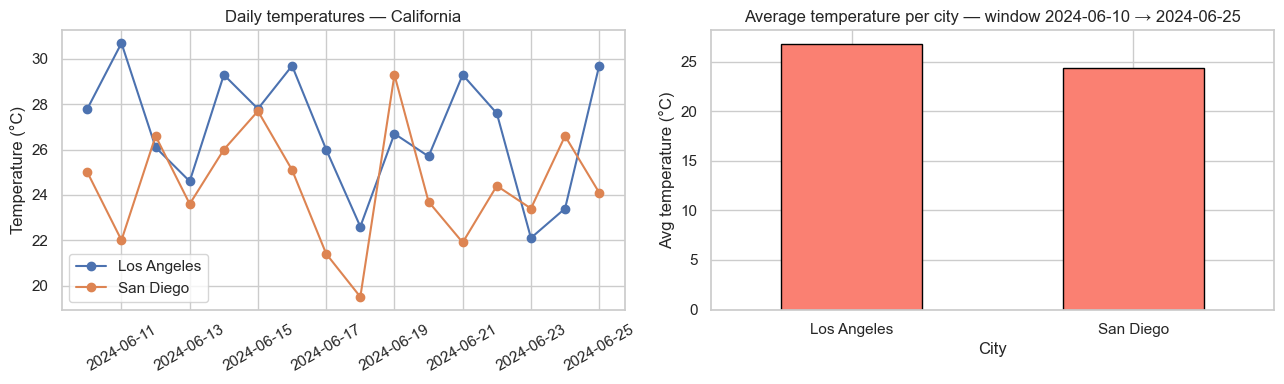

In [28]:
# Average temperature by city in the chosen window
avg_by_city = subset.groupby(level='City')['Temperature_C'].mean().round(2)
print('Average temperature per city:')
print(avg_by_city)

# Visualize: a line per city showing daily temperatures
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: line plot, daily temperatures per city
for city, sub in subset.groupby(level='City'):
    axes[0].plot(sub.index.get_level_values('Date'), sub['Temperature_C'],
                 marker='o', label=city)
axes[0].set_title(f'Daily temperatures — {target_state}')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend(); axes[0].tick_params(axis='x', rotation=30)

# Right: bar plot, average per city
avg_by_city.plot(kind='bar', ax=axes[1], color='salmon', edgecolor='black')
axes[1].set_title(f'Average temperature per city — window {date_start} → {date_end}')
axes[1].set_ylabel('Avg temperature (°C)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Exercise 3 — Dynamic Subplot Configuration

Tkinter does not display inside a Jupyter notebook. We replace it by a **simple variable `n_plots`** at the top of the cell (or by an `input()` prompt). The script then builds a 3×3 grid with that many plots, rotating through line / scatter / bar / histogram types.

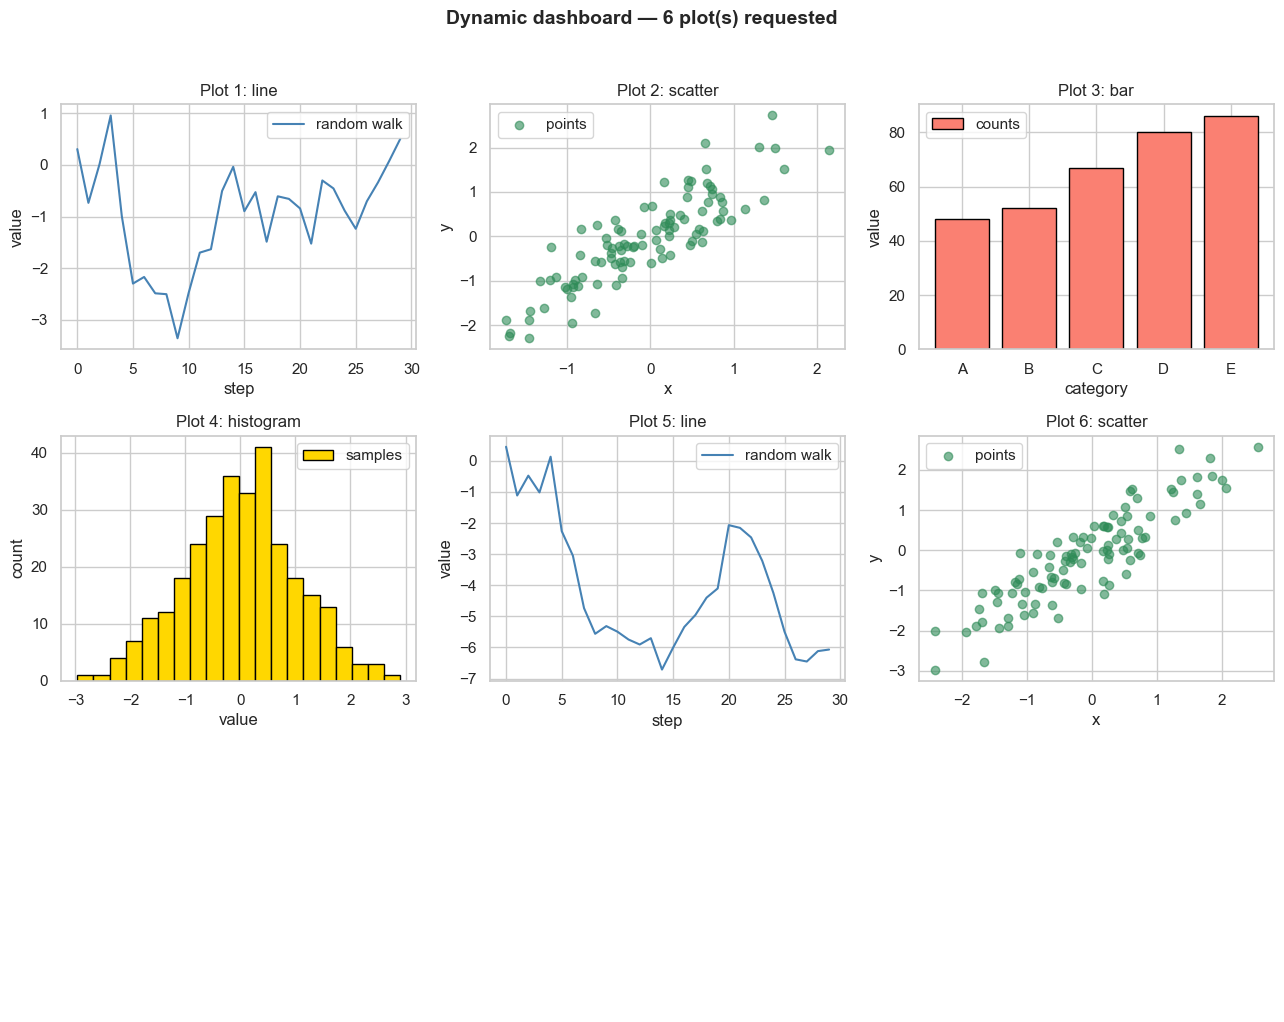

In [29]:
# ==================== USER INPUT ====================
# Change this number between 1 and 9. For a non-interactive run, just edit the value.
# (Replace with `n_plots = int(input('Number of plots (1-9): '))` for interactive mode.)
n_plots = 6
n_plots = max(1, min(9, n_plots))   # clamp into the valid range

# Available plot types — we cycle through them as we add subplots
plot_types = ['line', 'scatter', 'bar', 'histogram']

# ==================== 3x3 GRID ====================
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.ravel()   # flatten the 3x3 array into a 1-D list for easy indexing
rng = np.random.default_rng(42)

for i in range(9):
    ax = axes[i]
    if i >= n_plots:
        # Hide the unused axes so the user sees only the requested number
        ax.axis('off')
        continue

    ptype = plot_types[i % len(plot_types)]

    if ptype == 'line':
        x = np.arange(30); y = rng.normal(size=30).cumsum()
        ax.plot(x, y, color='steelblue', label='random walk'); ax.legend()
        ax.set_title(f'Plot {i+1}: line')
        ax.set_xlabel('step'); ax.set_ylabel('value')

    elif ptype == 'scatter':
        x = rng.normal(size=100); y = x + rng.normal(scale=0.5, size=100)
        ax.scatter(x, y, color='seagreen', alpha=0.6, label='points'); ax.legend()
        ax.set_title(f'Plot {i+1}: scatter')
        ax.set_xlabel('x'); ax.set_ylabel('y')

    elif ptype == 'bar':
        cats = list('ABCDE'); vals = rng.integers(10, 100, size=5)
        ax.bar(cats, vals, color='salmon', edgecolor='black', label='counts'); ax.legend()
        ax.set_title(f'Plot {i+1}: bar')
        ax.set_xlabel('category'); ax.set_ylabel('value')

    else:   # histogram
        data = rng.normal(size=300)
        ax.hist(data, bins=20, color='gold', edgecolor='black', label='samples'); ax.legend()
        ax.set_title(f'Plot {i+1}: histogram')
        ax.set_xlabel('value'); ax.set_ylabel('count')

fig.suptitle(f'Dynamic dashboard — {n_plots} plot(s) requested', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Exercises 4-6 — Wine dataset

We try to load a wine dataset (with `country`, `vintage`, `price_PLN`, `alcohol_%`, etc.). If no file is found we build a **synthetic wine dataset** so the next three exercises run end-to-end.

In [30]:
# ==================== LOAD WINE DATASET WITH GRACEFUL FALLBACK ====================
wine_candidates = ['wines.csv', 'wine_prices.csv', 'winemag-data_first150k.csv']
wine = None
for name in wine_candidates:
    p = os.path.join(BASE_DIR, name)
    if os.path.exists(p):
        wine = pd.read_csv(p)
        print('Loaded local file:', name)
        break

if wine is None:
    print('Using a synthetic wine dataset.')
    rng = np.random.default_rng(7)
    countries = ['France', 'Italy', 'Spain', 'Portugal', 'Chile',
                 'Germany', 'Argentina', 'USA']
    weights   = [0.30, 0.25, 0.15, 0.10, 0.08, 0.05, 0.04, 0.03]
    n = 1500
    wine = pd.DataFrame({
        'country'   : rng.choice(countries, size=n, p=weights),
        'vintage'   : rng.integers(2005, 2024, size=n),
        'alcohol_%' : np.round(rng.normal(13.5, 1.0, size=n), 1),
        'acidity'   : np.round(rng.normal(5.5, 1.2, size=n), 2),
        'residual_sugar': np.round(np.abs(rng.normal(3.0, 2.0, size=n)), 2),
    })
    # Price formula: base + country premium + age bonus + alcohol effect + noise
    country_premium = wine['country'].map({
        'France': 80, 'Italy': 60, 'Spain': 40, 'Portugal': 30,
        'Chile': 25, 'Germany': 35, 'Argentina': 22, 'USA': 55
    })
    age_bonus = (2024 - wine['vintage']) * 4
    wine['price_PLN'] = np.round(
        50 + country_premium + age_bonus + wine['alcohol_%']*3
        + rng.normal(0, 20, size=n), 2
    ).clip(lower=15)

print('Shape:', wine.shape)
wine.head()

Using a synthetic wine dataset.
Shape: (1500, 6)


,country,vintage,alcohol_%,acidity,residual_sugar,price_PLN
0,Spain,2015,13.8,6.56,5.52,173.83
1,Germany,2017,12.4,7.59,6.25,160.77
2,Portugal,2010,13.2,6.33,3.84,157.16
3,France,2018,13.3,6.43,1.49,187.25
4,Italy,2021,12.8,4.40,1.54,157.72


## Exercise 4 — Multi-dimensional Wine Analysis (FacetGrid)

In [31]:
# ==================== KEEP THE TOP 5 COUNTRIES BY NUMBER OF LISTINGS ====================
top5_countries = wine['country'].value_counts().head(5).index.tolist()
print('Top 5 countries:', top5_countries)

wine_top5 = wine[wine['country'].isin(top5_countries)].copy()

# Group by country + vintage and compute average price and average alcohol
agg = (wine_top5.groupby(['country', 'vintage'])
                .agg(avg_price=('price_PLN', 'mean'),
                     avg_alc  =('alcohol_%', 'mean'))
                .reset_index())
agg.head()

Top 5 countries: ['France', 'Italy', 'Spain', 'Portugal', 'Chile']


,country,vintage,avg_price,avg_alc
0,Chile,2005,185.856000,13.400000
1,Chile,2006,188.400000,13.725000
2,Chile,2007,191.396667,13.366667
3,Chile,2008,190.121250,13.675000
4,Chile,2009,164.915000,13.741667


In [ ]:
# ==================== FACETGRID-LIKE LAYOUT VIA sns.relplot ====================
# We use sns.relplot, the modern wrapper that:
# - builds a FacetGrid under the hood,
# - handles `size` + `hue` together without the seaborn 0.13+ legend bug.
#
# col='country'  -> one subplot per top-5 country
# col_wrap=3     -> 3 plots per row
# hue='country'  -> color per country (one color per panel)
# size='avg_alc' -> point size proportional to the average alcohol content
# sizes=(40, 350) -> min / max point size in pixels
# kind='scatter' -> scatter plot inside each facet
g = sns.relplot(
    data=agg,
    x='vintage', y='avg_price',
    col='country', col_wrap=3,
    hue='country', palette='Set2',
    size='avg_alc', sizes=(40, 350),
    kind='scatter',
    height=3.5, aspect=1.2,
    alpha=0.7,
)
g.set_axis_labels('Vintage', 'Average price (PLN)')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Average wine price vs vintage, per country (point size ∝ alcohol %)',
                  y=1.05, fontweight='bold')
plt.show()

## Exercise 5 — Predicting Wine Prices (Regression)

In [ ]:
# ==================== PREPROCESS ====================
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Target = price; features = everything else (numerical + categorical)
y = wine['price_PLN']
X = wine.drop(columns=['price_PLN'])

num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print('Numeric :', num_cols)
print('Categorical:', cat_cols)

preprocess = ColumnTransformer([
    ('num', StandardScaler(),                       num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# ==================== TRAIN TWO MODELS AND COMPARE ====================
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest'    : RandomForestRegressor(n_estimators=200, random_state=42)
}

results = {}
for name, model in models.items():
    pipe = Pipeline([('pre', preprocess), ('reg', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2   = r2_score(y_test, pred)
    results[name] = (pipe, pred, rmse, r2)
    print(f'{name:20s}  RMSE = {rmse:.2f}   R² = {r2:.3f}')

In [ ]:
# ==================== SCATTER PLOT: PREDICTED vs ACTUAL ====================
best_name = max(results, key=lambda k: results[k][3])   # highest R²
_, pred, rmse, r2 = results[best_name]

plt.figure(figsize=(7, 6))
plt.scatter(y_test, pred, alpha=0.5, color='steelblue', edgecolor='k')
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
plt.plot(lims, lims, 'r--', lw=2, label='perfect prediction')
plt.xlabel('Actual price (PLN)')
plt.ylabel('Predicted price (PLN)')
plt.title(f'Predicted vs Actual — {best_name}  (R² = {r2:.3f}, RMSE = {rmse:.2f})')
plt.legend()
plt.show()

## Exercise 6 — Clustering Similar Wines (KMeans + PCA)

In [ ]:
# ==================== PREPROCESS NUMERIC FEATURES ONLY ====================
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

features = ['alcohol_%', 'acidity', 'residual_sugar', 'price_PLN', 'vintage']
X_clust  = wine[features].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)
print('Scaled feature matrix:', X_scaled.shape)

In [ ]:
# ==================== FIND THE OPTIMAL K (ELBOW + SILHOUETTE) ====================
ks         = range(2, 9)
inertias   = []
sil_scores = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow method (inertia)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('inertia')

axes[1].plot(ks, sil_scores, marker='o', color='seagreen')
axes[1].set_title('Silhouette score (higher = better)')
axes[1].set_xlabel('k'); axes[1].set_ylabel('silhouette')
plt.tight_layout(); plt.show()

optimal_k = int(ks[int(np.argmax(sil_scores))])
print(f'Optimal k according to silhouette: {optimal_k}')

In [ ]:
# ==================== FIT FINAL KMEANS + 2D PCA PROJECTION ====================
km_final = KMeans(n_clusters=optimal_k, n_init=10, random_state=42).fit(X_scaled)
labels   = km_final.labels_

# Reduce the 5-D scaled space to 2-D for visualization
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
scat = plt.scatter(coords[:, 0], coords[:, 1], c=labels, cmap='tab10',
                   alpha=0.7, edgecolor='k')
plt.colorbar(scat, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title(f'KMeans clusters projected on 2-D PCA  (k = {optimal_k})')
plt.show()

In [ ]:
# ==================== CLUSTER PROFILES ====================
# Reattach the labels to the original feature space and look at the mean per cluster.
profile = X_clust.copy()
profile['cluster'] = labels
cluster_means = profile.groupby('cluster').mean().round(2)
print('Mean of each feature, per cluster:')
cluster_means

### How to read the cluster profiles
- Each row is a cluster, each column a feature.  
- A cluster with **higher `price_PLN` + higher `alcohol_%` + older `vintage`** corresponds to **premium aged wines**.  
- A cluster with **lower `price_PLN` + recent `vintage`** corresponds to **young everyday wines**.  
- Differences in `acidity` or `residual_sugar` may reveal stylistic clusters (dry vs sweet, fresh vs round).  
- The 2-D PCA plot shows whether the clusters are well separated. If clusters overlap heavily, the natural structure is weaker than KMeans assumes, and **hierarchical clustering** or **DBSCAN** may be worth trying.